In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 

from lsst.ip.isr import ShutterMotionProfile


In [48]:
filename_open = '/home/e/ebellm/u/stack/ip_isr/tests/data/MC_O_20250526_000095_shutterMotionProfileOpen.json'
sm_open = ShutterMotionProfile.readText(filename_open)
filename_close = '/home/e/ebellm/u/stack/ip_isr/tests/data/MC_O_20250526_000095_shutterMotionProfileClose.json'
sm_close = ShutterMotionProfile.readText(filename_close)

In [49]:
sm_open.metadata

OBSTYPE = "shutterMotionProfile"
shutterMotionProfile_SCHEMA = "ShutterMotionProfile"
shutterMotionProfile_VERSION = 1.0000000000000
INSTRUME = <Unknown>
RAFTNAME = <Unknown>
SLOTNAME = <Unknown>
DETECTOR = <Unknown>
DET_NAME = <Unknown>
DET_SER = <Unknown>
FILTER = <Unknown>
CALIB_ID = <Unknown>
SEQFILE = <Unknown>
SEQNAME = <Unknown>
SEQCKSUM = <Unknown>
CALIBCLS = "lsst.ip.isr.shutterMotion.ShutterMotionProfile"
fileName = "MC_O_20250526_000095_shutterMotionProfileOpen.json"
fileType = "shutterMotionProfile"
obsId = "MC_O_20250526_000095"
version = 1.0000000000000
startPosition = 750.78034791487
targetPosition = 0.0000000000000
endPosition = -0.64782587480000
targetDuration = 900
actionDuration = 901
side = "PLUSX"
isOpen = 1
startTime_tai = "2025-05-27T01:39:12.923"
startTime_mjd = 60822.068899572


In [50]:
sm_open.calculateMidpoint()

(np.float64(0.45052044442394185), np.float64(0.44985220648315977))

Plot the raw positions and times from the profile

Text(0, 0.5, 'Position')

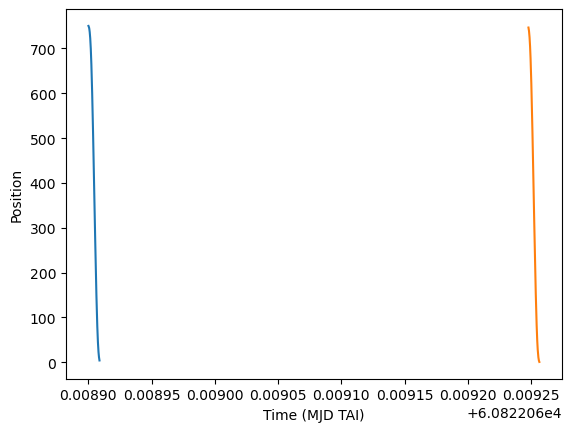

In [51]:
plt.plot(sm_open.hall_time_mjd, sm_open.hall_position)
plt.plot(sm_close.hall_time_mjd, sm_close.hall_position)


plt.xlabel('Time (MJD TAI)')
plt.ylabel('Position')

In [78]:
type(sm_open.hall_time_mjd[0])

float

Plot the fit (in normalized coordinates)

Text(0, 0.5, 'Position')

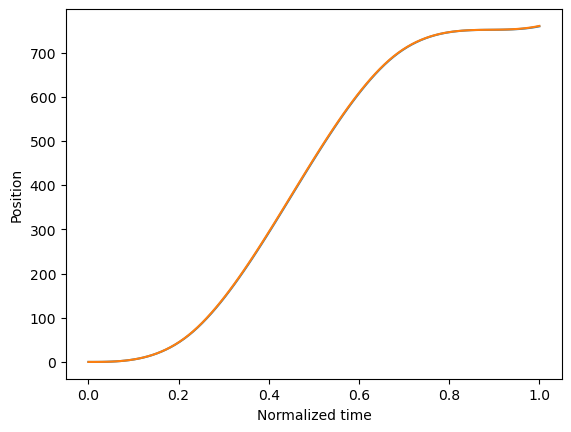

In [52]:
t = np.linspace(0,1,100)
plt.plot(t, [sm_open.shutterPosition(ti) for ti in t])
plt.plot(t, [sm_close.shutterPosition(ti) for ti in t])

plt.xlabel('Normalized time')
plt.ylabel('Position')

Let's convince ourselves we can plot model on top of data.  From CTN-002 section 4,

> To compare the model with data, subtract both startTime and $𝑡_0$ from the time stamps. The model position
also needs to subtract startPosition if moving towards the positive direction (startPosition <
endPosition), or be subtracted by startPosition otherwise.

In [24]:
def normalize_data(sm):

    # doesn't appear we should use the actual duration (sm.metadata['actionDuration']) 
    # or displacement np.abs(sm.metadata['endPosition'] - sm.metadata['startPosition'])

    modelIndex = sm._getModelIndexByName('hallSensorFit')
    t0 = sm.fit_start_time[modelIndex]
    t = (np.array(sm.hall_time_mjd) - sm.metadata['startTime_mjd']) /  (1 / 24 / 3600) - t0

    
    side = sm.metadata['side']
    if side == 'PLUSX':
        s = (sm.metadata['startPosition'] - np.array(sm.hall_position)) 
    elif side == 'MINUSX':
        s = (np.array(sm.hall_position) - sm.metadata['startPosition'])

    return t, s

Text(0, 0.5, 'Position [mm]')

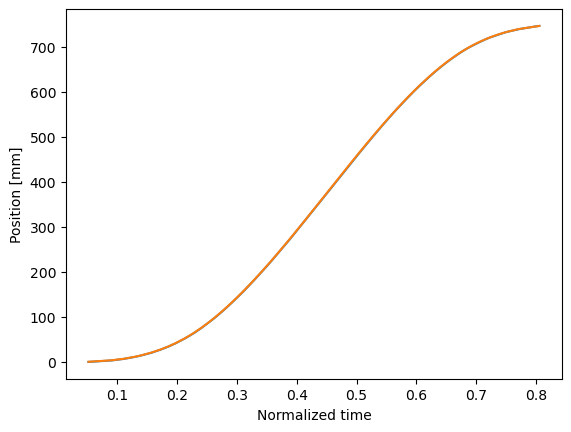

In [25]:

norm_hall_t, norm_hall_s = normalize_data(sm_open)
plt.plot(norm_hall_t, norm_hall_s)

plt.plot(norm_hall_t, [sm_open.shutterPosition(ti) for ti in norm_hall_t])


plt.xlabel('Normalized time')
plt.ylabel('Position [mm]')

Text(0, 0.5, 'Position Residual [mm]')

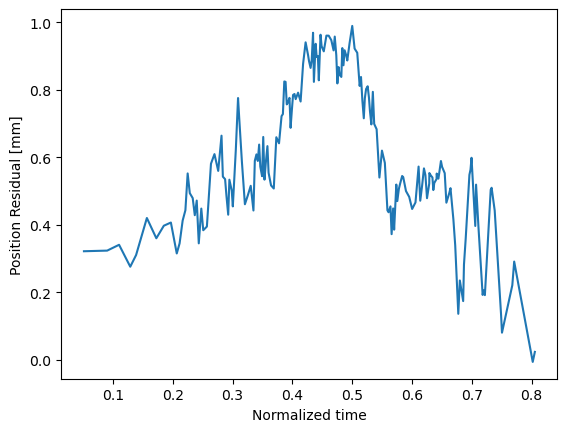

In [26]:
plt.plot(norm_hall_t, [sm_open.shutterPosition(ti) - norm_hall_s[i] for i, ti in enumerate(norm_hall_t)])


plt.xlabel('Normalized time')
plt.ylabel('Position Residual [mm]')

Now let's try going the other direction, from the fits to the data space--which is what we need to do to handle the offsets.

In [98]:
def normalized_time_to_mjd(sm, t):
    
    modelIndex = sm._getModelIndexByName('hallSensorFit')
    t0 = sm.fit_start_time[modelIndex]
    # I don't understand why we don't need the action direction here.  Maybe because the model limits
    # extend past the actual physical travel?
    mjd = (t + t0) / 24 / 3600 +  sm.metadata['startTime_mjd']

    return mjd

def denormalize_fit(sm, t):
    # given input normalized time, return MJD and physical position

    mjd = normalized_time_to_mjd(sm, t)

    s = sm.shutterPosition(t)
    
    side = sm.metadata['side']
    if side == 'PLUSX':
        x = (sm.metadata['startPosition'] - s) 
    elif side == 'MINUSX':
        x = (s - sm.metadata['startPosition'])

    return mjd, x

In [86]:
t = np.linspace(0,1,100)
model_mjd_open, model_x_open = denormalize_fit(sm_open, t)
model_mjd_close, model_x_close = denormalize_fit(sm_close, t)

Text(0, 0.5, 'Position')

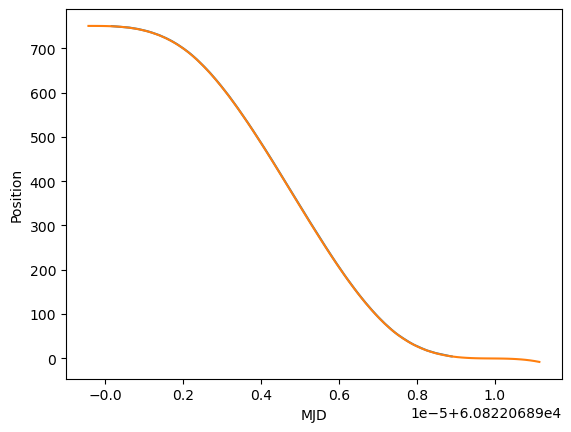

In [87]:

plt.plot(sm_open.hall_time_mjd, sm_open.hall_position)

plt.plot(model_mjd_open, model_x_open)
plt.xlabel('MJD')
plt.ylabel('Position')

to match the offsets we will need the ccs value

In [65]:
def encoder_to_ccs(x, side):

    A0 = 375.0
    B = -1

    if side == 'PLUSX':
        A1 = 0.90
    elif side == 'MINUSX':
        A1 = -0.36
        
    Xccs = A0 + A1 + B * x

    return Xccs

In [88]:
model_xccs_open = encoder_to_ccs(model_x_open, sm_open.metadata['side'])
model_xccs_close = encoder_to_ccs(model_x_close, sm_close.metadata['side'])

since the function is monotonic I can interpolate it by swapping x and y rather than needing a solver


or is there an analytic inverse?

Text(0, 0.5, 'Relative time (s)')

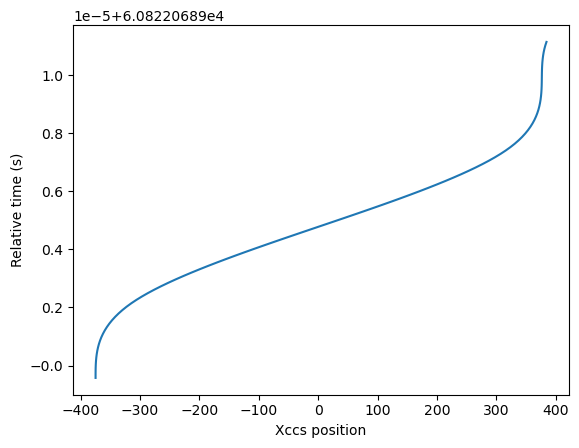

In [67]:

plt.plot(model_xccs_open, model_mjd_open)
plt.xlabel('Xccs position')
plt.ylabel('Relative time (s)')

In [70]:
def mjd_at_xccs(xccs, model_xccs, model_mjd):
    return np.interp(xccs, model_xccs, model_mjd)

## offsets

In [30]:
df = pd.read_csv('beam_at_L3S1_-z9.618_rot0_evaluated.csv')

In [31]:
set(df['level'])

{0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99}

In [32]:
w50 = df['level'] == 0.5

Text(0, 0.5, 'Yccs [mm]')

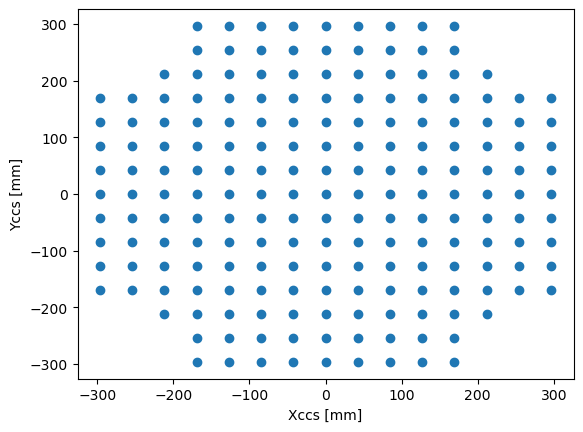

In [111]:
plt.scatter(df.loc[w50, 'xccs_mm'], df.loc[w50, 'yccs_mm'])
plt.xlabel('Xccs [mm]')
plt.ylabel('Yccs [mm]')

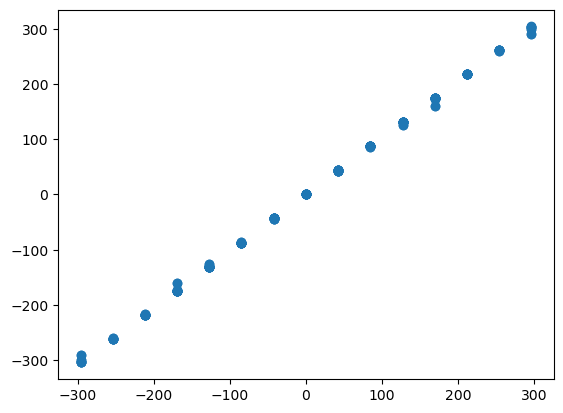

In [34]:
plt.scatter(df.loc[w50, 'xccs_mm'], df.loc[w50, 'beam_median_shutterpos'])

In [89]:
open_time = mjd_at_xccs(df.loc[w50, 'xccs_mm'], model_xccs_open, model_mjd_open)
close_time = mjd_at_xccs(df.loc[w50, 'xccs_mm'], model_xccs_close, model_mjd_close)

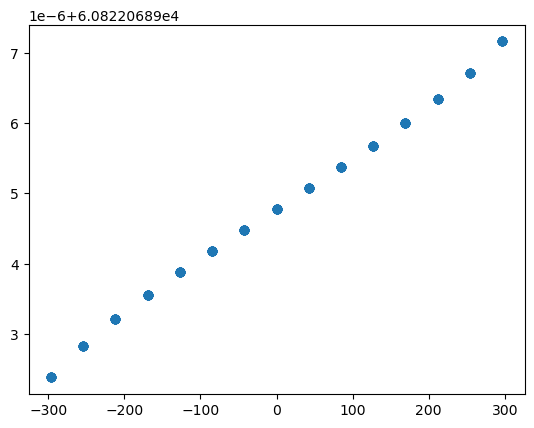

In [90]:
plt.scatter(df.loc[w50, 'xccs_mm'], open_time)

In [92]:
midpoint_time = (close_time + open_time)/2.
duration = (close_time - open_time) * 24 * 3600

Text(0, 0.5, 'Exposure midpoint (MJD) [d]')

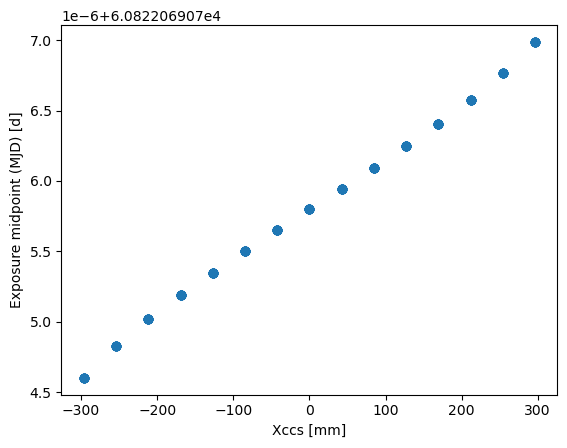

In [96]:
plt.scatter(df.loc[w50, 'xccs_mm'], midpoint_time)
plt.xlabel('Xccs [mm]')
plt.ylabel('Exposure midpoint (MJD) [d]')

Text(0, 0.5, 'Exposure duration (50-50 illumination) [s]')

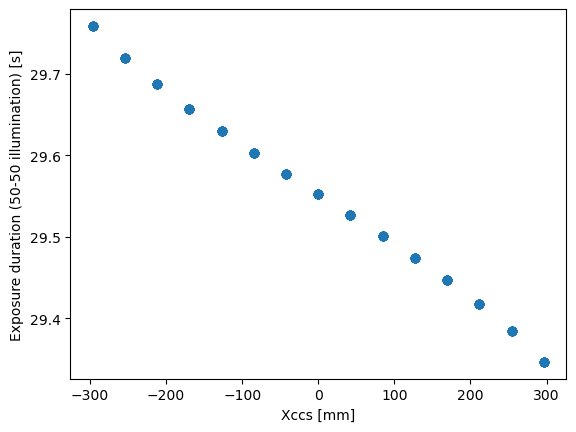

In [95]:
plt.scatter(df.loc[w50, 'xccs_mm'], duration)
plt.xlabel('Xccs [mm]')
plt.ylabel('Exposure duration (50-50 illumination) [s]')

In [104]:
midpoint_mjd_open = normalized_time_to_mjd(sm_open, sm_open.calculateMidpoint()[0])
midpoint_mjd_close = normalized_time_to_mjd(sm_close, sm_close.calculateMidpoint()[0])

In [105]:
midpoint_mjd = (midpoint_mjd_close + midpoint_mjd_open)/2.
midpoint_duration = (midpoint_mjd_close - midpoint_mjd_open) * 24. * 3600
midpoint_duration

np.float64(30.002452433109283)

In [106]:
midpoint_mjd

np.float64(60822.069078412)

Text(0, 0.5, 'Offset from midpoint time [s]')

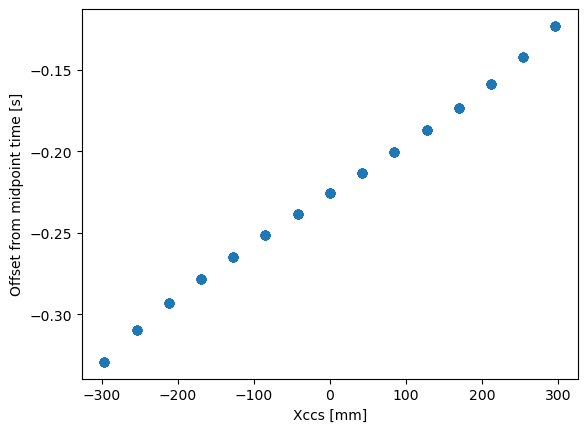

In [108]:
plt.scatter(df.loc[w50, 'xccs_mm'], (midpoint_time-midpoint_mjd)*24*3600)
plt.xlabel('Xccs [mm]')
plt.ylabel('Offset from midpoint time [s]')

Text(0, 0.5, 'Offset from midpoint duration [s]')

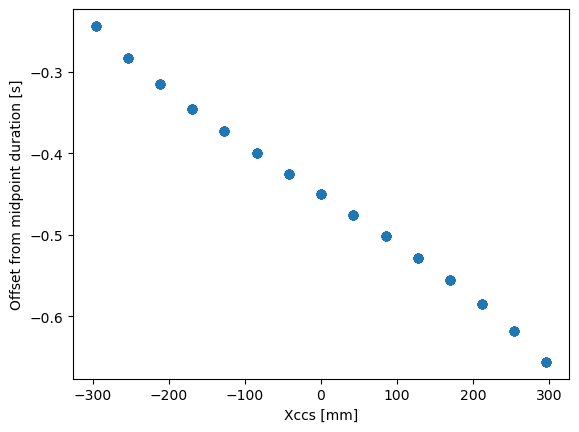

In [109]:
plt.scatter(df.loc[w50, 'xccs_mm'], (duration - midpoint_duration))
plt.xlabel('Xccs [mm]')
plt.ylabel('Offset from midpoint duration [s]')